In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

In [2]:
# === Load and preprocess CIFAR-10 ===
(x_train, _), _ = cifar10.load_data()
x_train = x_train.astype("float32") / 255.0

In [3]:
# === Define latent dimension ===
latent_dim = 128

# === VAE Sampling Layer ===
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


In [4]:
# === Build the VAE encoder ===
def build_encoder():
    encoder_inputs = tf.keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    z_mean = layers.Dense(latent_dim)(x)
    z_log_var = layers.Dense(latent_dim)(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
    return encoder

In [5]:
# === Build the VAE decoder ===
def build_decoder():
    latent_inputs = tf.keras.Input(shape=(latent_dim,))
    x = layers.Dense(8 * 8 * 64, activation="relu")(latent_inputs)
    x = layers.Reshape((8, 8, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
    decoder = Model(latent_inputs, decoder_outputs, name="decoder")
    return decoder

In [6]:
# === VAE class ===
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def compile(self, optimizer):
        super(VAE, self).compile()
        self.optimizer = optimizer
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            # 🔧 FIXED: removed axis=3 from reduce_sum
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }



In [7]:
# === Build and train the VAE ===
encoder = build_encoder()
decoder = build_decoder()
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())
vae.fit(x_train, epochs=20, batch_size=256)



Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - kl_loss: 1.8733 - loss: 697.4662 - reconstruction_loss: 695.5930
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - kl_loss: 9.3060 - loss: 657.4878 - reconstruction_loss: 648.1817
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - kl_loss: 12.4616 - loss: 650.5654 - reconstruction_loss: 638.1037
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - kl_loss: 13.9913 - loss: 642.6807 - reconstruction_loss: 628.6896
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - kl_loss: 13.9437 - loss: 637.9724 - reconstruction_loss: 624.0287
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - kl_loss: 13.9881 - loss: 634.8185 - reconstruction_loss: 620.8303
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - kl_loss: 14.2463 - loss: 633.8356 - reconstruction_loss: 619.5895
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - kl_loss: 14.5540 - loss: 632.6854 - reconstruction_loss: 618.1315
Epoch 9/20
196/196 ━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


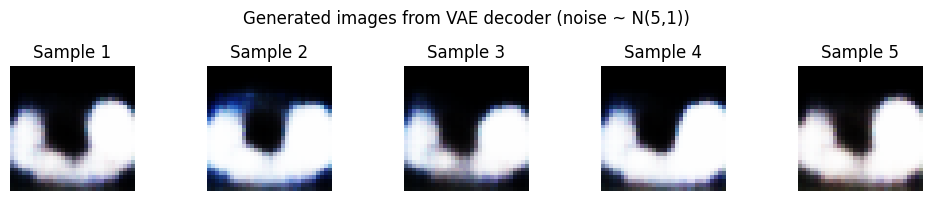

In [8]:
# === Generate 5 images using noise with mean=5 and std=1 ===
noise_vectors = np.random.normal(loc=5.0, scale=1.0, size=(5, latent_dim))
generated_images = decoder.predict(noise_vectors)

# === Visualize generated images ===
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i])
    plt.axis('off')
    plt.title(f"Sample {i+1}")
plt.suptitle("Generated images from VAE decoder (noise ~ N(5,1))")
plt.tight_layout()
plt.show()